# 2. Q-learning tabulaire

Agent Q-learning tabulaire simulé sur le même MDP que le notebook 1. L'agent n'accède à $\lambda(p)$ qu'à travers des tirages de Bernoulli — jamais directement — via `sample_transition`. On entraîne un agent unique ici pour vérifier que l'implémentation converge qualitativement vers $Q^*$ avant de lancer les comparaisons statistiques du notebook 3.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)


In [2]:
from dataclasses import replace
from src.config import DEFAULT_CONFIG
from src.dp import solve_dp, plot_price_heatmap
from src.qlearning import run_qlearning, polynomial_step, linear_epsilon
from src.evaluation import make_evaluator

# On réduit légèrement le nombre d'épisodes par défaut pour un run de démo rapide ;
# le notebook 3 utilise des budgets calibrés par expérience.
cfg = replace(DEFAULT_CONFIG, N_EPISODES=15_000)
Q_star, V_star, pi_idx_star = solve_dp(cfg)
print(f"V*(C,T) = {V_star[cfg.C, cfg.T]:.2f}")

V*(C,T) = 986.52


## 2.1 Entraînement d'un agent unique

In [3]:
rng = np.random.default_rng(0)
step_fn = polynomial_step(alpha0=cfg.STEP_ALPHA0, omega=cfg.STEP_OMEGA)
eps_fn = linear_epsilon(cfg.N_EPISODES, cfg.EPS_START, cfg.EPS_END)
evaluator = make_evaluator(cfg, Q_star, V_star, rng, n_mc_episodes=cfg.N_MC_EPISODES)

import time
t0 = time.perf_counter()
Q, visits, history = run_qlearning(
    cfg, cfg.N_EPISODES, step_fn, eps_fn, rng,
    eval_every=cfg.EVAL_EVERY, eval_fn=evaluator,
)
print(f"Entraînement terminé en {time.perf_counter()-t0:.1f}s, "
      f"{len(history)} points d'évaluation")

Entraînement terminé en 28.4s, 76 points d'évaluation


## 2.2 Courbes d'apprentissage

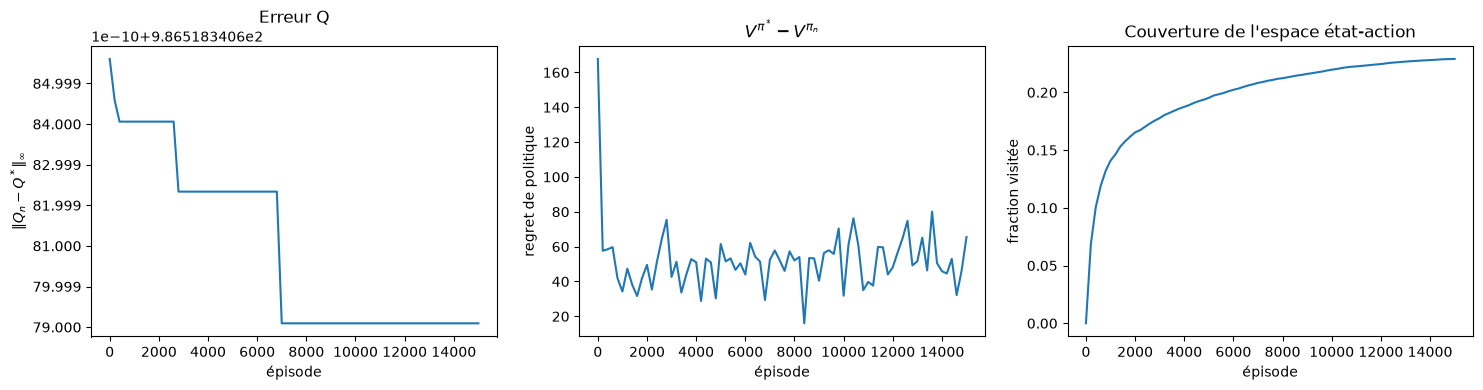

In [4]:
episodes = np.array([h["episode"] for h in history])
q_err = np.array([h["q_error_inf"] for h in history])
regret = np.array([h["regret"] for h in history])
coverage = np.array([h["coverage"] for h in history])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(episodes, q_err)
axes[0].set_xlabel("épisode"); axes[0].set_ylabel(r"$\|Q_n - Q^*\|_\infty$")
axes[0].set_title("Erreur Q")

axes[1].plot(episodes, regret)
axes[1].set_xlabel("épisode"); axes[1].set_ylabel("regret de politique")
axes[1].set_title(r"$V^{\pi^*} - V^{\pi_n}$")

axes[2].plot(episodes, coverage)
axes[2].set_xlabel("épisode"); axes[2].set_ylabel("fraction visitée")
axes[2].set_title("Couverture de l'espace état-action")
fig.tight_layout()
fig.savefig(OUT / "single_run_learning_curves.png", dpi=150)
plt.show()

## 2.3 Comparaison visuelle des politiques

Carte de chaleur du prix appris (glouton sur $Q_n$) contre le prix optimal DP.

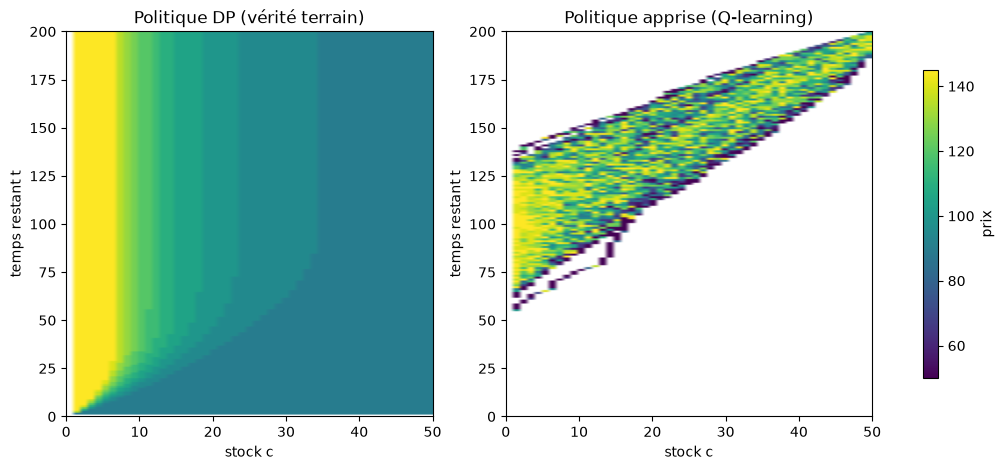

In [5]:
pi_idx_learned = np.argmax(Q, axis=2)
pi_idx_learned[visits.sum(axis=2) == 0] = -1  # états jamais visités : non défini

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pi, title in [
    (axes[0], pi_idx_star, "Politique DP (vérité terrain)"),
    (axes[1], pi_idx_learned, "Politique apprise (Q-learning)"),
]:
    prices_grid = np.where(pi >= 0, cfg.prices[np.clip(pi, 0, None)], np.nan)
    im = ax.imshow(prices_grid.T, origin="lower", aspect="auto", cmap="viridis",
                    extent=[0, cfg.C, 0, cfg.T], vmin=cfg.P_MIN, vmax=cfg.P_MAX)
    ax.set_xlabel("stock c"); ax.set_ylabel("temps restant t"); ax.set_title(title)
fig.colorbar(im, ax=axes, label="prix", shrink=0.8)
fig.savefig(OUT / "policy_comparison.png", dpi=150)
plt.show()